# E-commerce Revenue & Customer Analytics

This project analyzes an e-commerce retail dataset to identify revenue trends, top-performing products, and customer purchasing behavior.

Dataset: Online Retail II (Dec 2010 - Dec 2011)

Tools Used:
- Python (Pandas)
- SQL (SQLite)
- Data Visualization (Matplotlib / Seaborn)

## 1. Import Libraries

In [20]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Load Dataset
The dataset is loaded from the Online Retail Excel file containing transactions from Dec 2010 to Dec 2011.

In [21]:
df=pd.read_excel("online_retail.xlsx",sheet_name="Year 2010-2011")
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


## 3. Initial Data Exploration

We inspect the dataset structure, missing values, and basic statistics.

In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541910 entries, 0 to 541909
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      541910 non-null  object        
 1   StockCode    541910 non-null  object        
 2   Description  540456 non-null  object        
 3   Quantity     541910 non-null  int64         
 4   InvoiceDate  541910 non-null  datetime64[ns]
 5   Price        541910 non-null  float64       
 6   Customer ID  406830 non-null  float64       
 7   Country      541910 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


In [23]:
df.describe()

,Quantity,InvoiceDate,Price,Customer ID
count,541910.000000,541910,541910.000000,406830.000000
mean,9.552234,2011-07-04 13:35:22.342307584,4.611138,15287.684160
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.080957,NaN,96.759765,1713.603074


In [24]:
df.shape

(541910, 8)

In [25]:
df.isnull().sum()

Invoice             0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
Price               0
Customer ID    135080
Country             0
dtype: int64

In [26]:
df.Country.value_counts().head(10)

Country
United Kingdom    495478
Germany             9495
France              8558
EIRE                8196
Spain               2533
Netherlands         2371
Belgium             2069
Switzerland         2002
Portugal            1519
Australia           1259
Name: count, dtype: int64

## 4. Data Cleaning

The following steps were applied:

- Removed rows with missing Customer ID
- Removed negative quantities (returns)
- Removed rows where price ≤ 0
- Converted Customer ID to integer

In [35]:
df = df.dropna(subset=["Customer ID"])
df["Customer ID"] = df["Customer ID"].astype(int)

df = df[df["Quantity"] > 0]
df = df[df["Price"] > 0]

## 5. Feature Engineering

New features were created to support business analysis.

In [37]:
df["Revenue"]=df["Quantity"]*df["Price"]

In [38]:
df['Year']=df['InvoiceDate'].dt.year
df['Month_Name']=df['InvoiceDate'].dt.month_name()
df['Month_Num']=df['InvoiceDate'].dt.month
df['Day']=df['InvoiceDate'].dt.day

## 6. Dataset After Cleaning

In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 397885 entries, 0 to 541909
Data columns (total 13 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      397885 non-null  object        
 1   StockCode    397885 non-null  object        
 2   Description  397885 non-null  object        
 3   Quantity     397885 non-null  int64         
 4   InvoiceDate  397885 non-null  datetime64[ns]
 5   Price        397885 non-null  float64       
 6   Customer ID  397885 non-null  int64         
 7   Country      397885 non-null  object        
 8   Revenue      397885 non-null  float64       
 9   Year         397885 non-null  int32         
 10  Month_Name   397885 non-null  object        
 11  Month_Num    397885 non-null  int32         
 12  Day          397885 non-null  int32         
dtypes: datetime64[ns](1), float64(2), int32(3), int64(2), object(5)
memory usage: 37.9+ MB


In [32]:
df.shape

(397885, 13)

## 7. Save Cleaned Dataset

In [33]:
df.to_csv("ecommerce_cleaned.csv",index=False)

## 8. Load Data into SQLite Database

In [ ]:
conn=sqlite3.connect("ecommerce.db")
df.to_sql("sales",conn,if_exists="replace",index=False)
conn.close()

## 9. SQL Business Analysis

SQL queries are used to answer key business questions related to revenue trends, product performance, and customer behavior.

In [39]:
conn = sqlite3.connect("ecommerce.db")

### Total Revenue

**Business Question:**  
What is the total revenue generated during the analysis period?

In [40]:
query = """
SELECT SUM(Revenue) AS Total_Revenue
FROM sales
"""

total_revenue = pd.read_sql(query, conn)
total_revenue

,Total_Revenue
0,8911425.904


### Monthly Revenue Trend

**Business Question:**  
How does revenue change throughout the year?

In [42]:
query = """
SELECT
    Year,
    Month_Num,
    SUM(Revenue) AS Monthly_Revenue
FROM sales
WHERE Year = 2011
GROUP BY Year, Month_Num
ORDER BY Year, Month_Num
"""

monthly_revenue = pd.read_sql(query, conn)
monthly_revenue.set_index("Year")

,Month_Num,Monthly_Revenue
Year,,
2011,1,569445.040
2011,2,447137.350
2011,3,595500.760
2011,4,469200.361
2011,5,678594.560
2011,6,661213.690
2011,7,600091.011
2011,8,645343.900
2011,9,952838.382


### Top Products by Revenue

**Business Question:**  
Which products generate the highest revenue?

In [44]:
query = """
SELECT
    Description,
    SUM(Revenue) AS Total_Revenue
FROM sales
GROUP BY Description
ORDER BY Total_Revenue DESC
LIMIT 10
"""

top_products_revenue = pd.read_sql(query, conn)
top_products_revenue.set_index("Description")

,Total_Revenue
Description,
"PAPER CRAFT , LITTLE BIRDIE",168469.60
REGENCY CAKESTAND 3 TIER,142592.95
WHITE HANGING HEART T-LIGHT HOLDER,100448.15
JUMBO BAG RED RETROSPOT,85220.78
MEDIUM CERAMIC TOP STORAGE JAR,81416.73
POSTAGE,77821.96
PARTY BUNTING,68844.33
ASSORTED COLOUR BIRD ORNAMENT,56580.34
Manual,53779.93


### Top Products by Quantity

**Business Question:**  
Which products are purchased most frequently?

In [47]:
query = """
SELECT
    Description,
    SUM(Quantity) AS Total_Quantity_Sold
FROM sales
GROUP BY Description
ORDER BY Total_Quantity_Sold DESC
LIMIT 10
"""

top_products_quantity = pd.read_sql(query, conn)
top_products_quantity.set_index("Description")

,Total_Quantity_Sold
Description,
"PAPER CRAFT , LITTLE BIRDIE",80995
MEDIUM CERAMIC TOP STORAGE JAR,77916
WORLD WAR 2 GLIDERS ASSTD DESIGNS,54415
JUMBO BAG RED RETROSPOT,46181
WHITE HANGING HEART T-LIGHT HOLDER,36725
ASSORTED COLOUR BIRD ORNAMENT,35362
PACK OF 72 RETROSPOT CAKE CASES,33693
POPCORN HOLDER,30931
RABBIT NIGHT LIGHT,27202


### Revenue by Country

**Business Question:**  
Which countries contribute the most revenue?

In [49]:
query = """
SELECT
    Country,
    SUM(Revenue) AS Total_Revenue
FROM sales
GROUP BY Country
ORDER BY Total_Revenue DESC
LIMIT 10
"""

country_revenue = pd.read_sql(query, conn)
country_revenue.set_index("Country")

,Total_Revenue
Country,
United Kingdom,7308391.554
Netherlands,285446.340
EIRE,265545.900
Germany,228867.140
France,209042.050
Australia,138521.310
Spain,61577.110
Switzerland,56443.950
Belgium,41196.340


## 10. Data Visualization

Visualizations help reveal trends and patterns in revenue, product sales, and geographic performance.

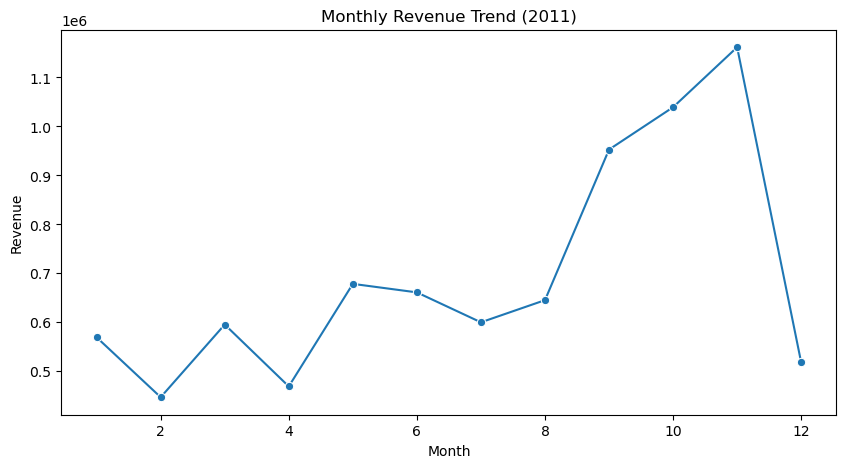

In [50]:
plt.figure(figsize=(10,5))

sns.lineplot(
    data=monthly_revenue,
    x="Month_Num",
    y="Monthly_Revenue",
    marker="o"
)

plt.title("Monthly Revenue Trend (2011)")
plt.xlabel("Month")
plt.ylabel("Revenue")

plt.show()

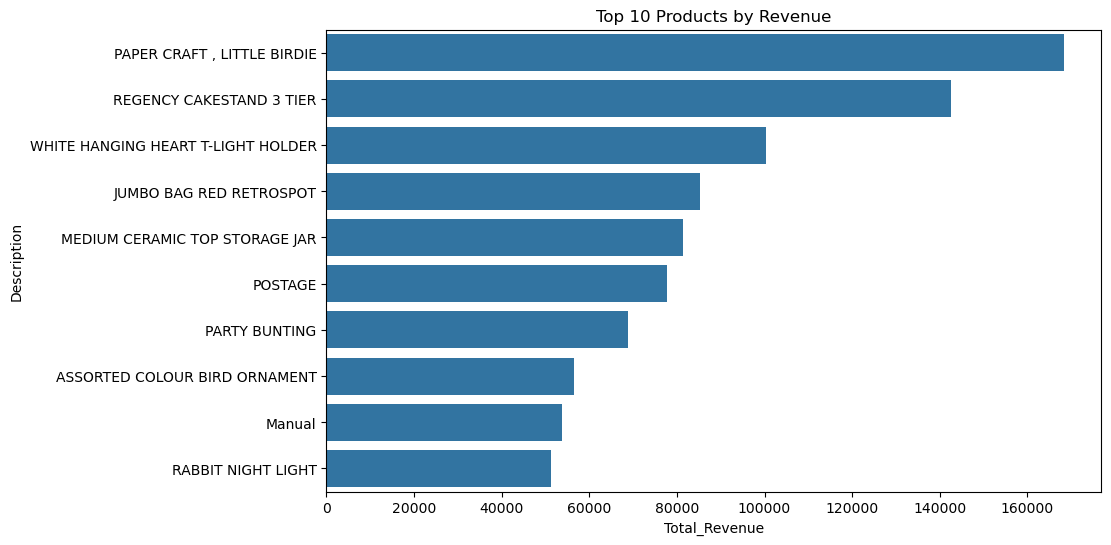

In [51]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=top_products_revenue,
    x="Total_Revenue",
    y="Description"
)

plt.title("Top 10 Products by Revenue")

plt.show()

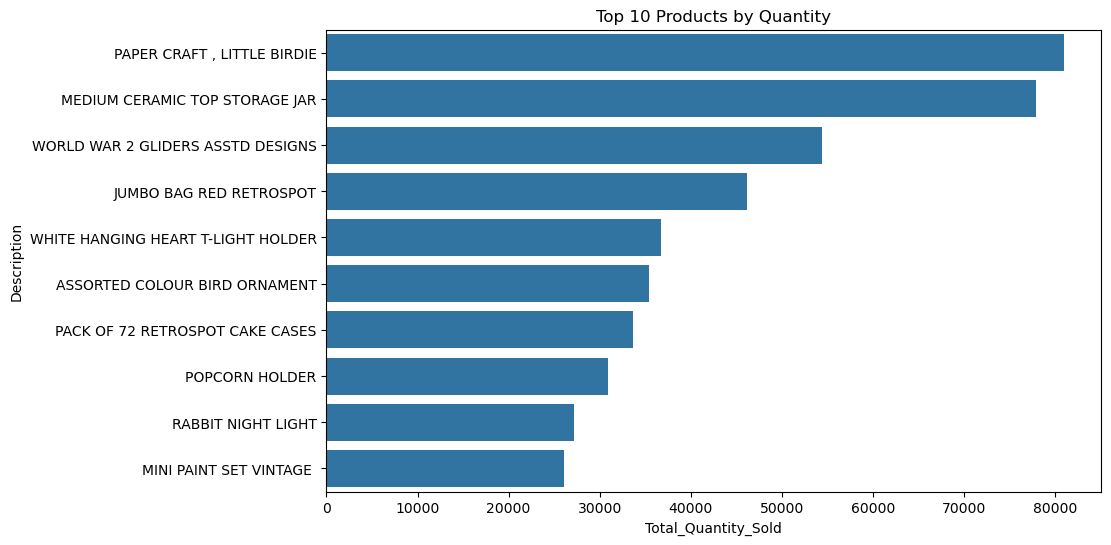

In [52]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=top_products_quantity,
    x="Total_Quantity_Sold",
    y="Description"
)

plt.title("Top 10 Products by Quantity")

plt.show()

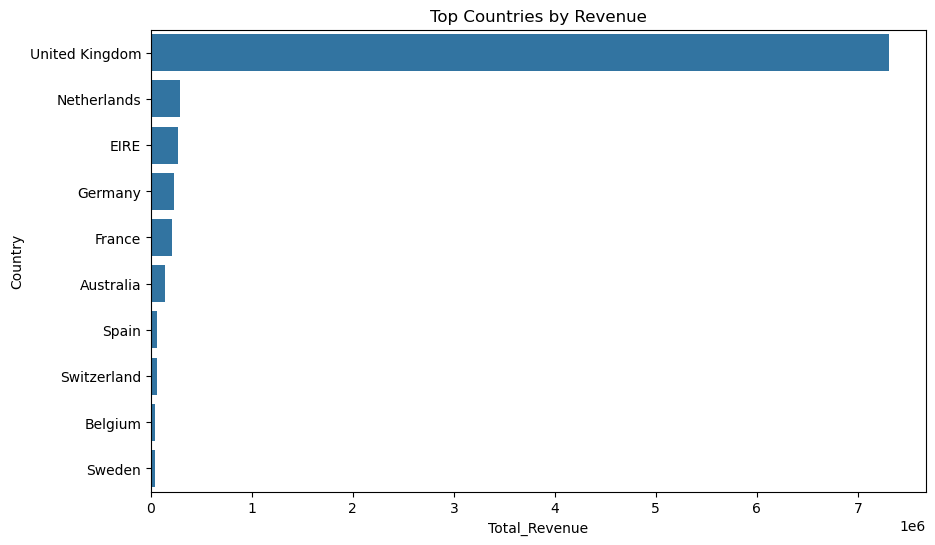

In [53]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=country_revenue,
    x="Total_Revenue",
    y="Country"
)

plt.title("Top Countries by Revenue")

plt.show()

### Close Database Connection


In [54]:
conn.close()

## 11. Key Business Insights

• Revenue shows clear variation across months, indicating seasonal purchasing behavior.

• A small number of products generate a significant portion of total revenue, suggesting product demand concentration.

• Some products sell in high quantities but generate lower revenue, indicating lower-priced items with high demand.

• Revenue is heavily concentrated in a few countries, with the United Kingdom contributing the majority of sales.

• Customer purchasing behavior shows that a relatively small group of customers contributes a large share of revenue.